<a href="https://colab.research.google.com/github/Kanishk-blip/-git_test-/blob/main/Solar_Panel_5thapar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 📦 1. Upload and Extract Dataset
from google.colab import files
import zipfile, os

uploaded = files.upload()  # Upload "archive (1).zip"

with zipfile.ZipFile("archive (1).zip", 'r') as zip_ref:
    zip_ref.extractall("solar_dataset")

print("✅ Dataset extracted.")


Saving archive (1).zip to archive (1).zip
✅ Dataset extracted.


In [ ]:
# 🧹 2. Organize Images (Cleaned with pathlib)
from pathlib import Path
import shutil

def organize_data():
    bird = Path("solar_dataset/Faulty_solar_panel/Bird-drop")
    clean = Path("solar_dataset/Faulty_solar_panel/Clean")
    target = Path("processed_dataset_binary")

    for subfolder in ["Bird_Dropping", "Clean_Panel"]:
        (target / subfolder).mkdir(parents=True, exist_ok=True)

    for img in bird.rglob("*"):
        if img.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            shutil.copy(img, target / "Bird_Dropping")

    for img in clean.rglob("*"):
        if img.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            shutil.copy(img, target / "Clean_Panel")

    print("✅ Data organized into Bird_Dropping and Clean_Panel.")

organize_data()


✅ Data organized into Bird_Dropping and Clean_Panel.


In [ ]:
# 🔧 3. Setup Data Generators
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    "processed_dataset_binary",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    "processed_dataset_binary",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)


Found 321 images belonging to 2 classes.
Found 79 images belonging to 2 classes.


In [ ]:
# 🤖 4. Build Transfer Learning Model with MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

base_model = MobileNetV2(input_shape=img_size + (3,), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# 🚀 5. Train Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

model.save("bird_drop_detector_final.h5")
print("✅ Model trained and saved.")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6058 - loss: 0.6824

11/11 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.6158 - loss: 0.6709 - val_accuracy: 0.8734 - val_loss: 0.2996
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.8367 - loss: 0.3614 - val_accuracy: 0.8608 - val_loss: 0.3624
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9396 - loss: 0.1783

11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9389 - loss: 0.1795 - val_accuracy: 0.8987 - val_loss: 0.2473
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9471 - loss: 0.1560

11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9468 - loss: 0.1563 - val_accuracy: 0.9114 - val_loss: 0.2137
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9694 - loss: 0.0989

11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9686 - loss: 0.1011 - val_accuracy: 0.9494 - val_loss: 0.1920
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.9674 - loss: 0.1081 - val_accuracy: 0.9114 - val_loss: 0.2015
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9731 - loss: 0.0735 - val_accuracy: 0.9620 - val_loss: 0.1942
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9818 - loss: 0.0776 - val_accuracy: 0.9114 - val_loss: 0.2335


✅ Model trained and saved.


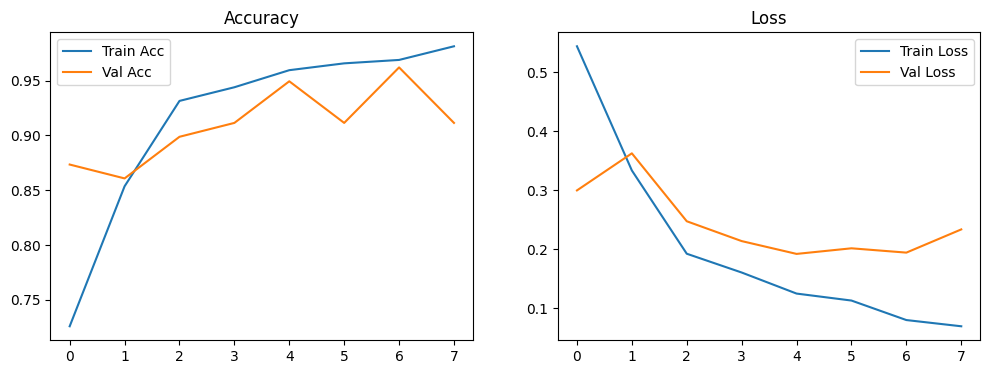

In [ ]:
# 📈 6. Plot Training Performance
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend(); plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend(); plt.title("Loss")

plt.show()


In [ ]:
base_model.trainable = True
# Freeze all but the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_data, validation_data=val_data, epochs=2, callbacks=callbacks)


Epoch 1/2
11/11 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.8355 - loss: 0.5109 - val_accuracy: 0.6709 - val_loss: 3.9884
Epoch 2/2
11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9721 - loss: 0.0775 - val_accuracy: 0.6329 - val_loss: 9.0548


3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step
Classification Report:
               precision    recall  f1-score   support

Bird_Dropping       0.47      0.17      0.25        41
  Clean_Panel       0.47      0.79      0.59        38

     accuracy                           0.47        79
    macro avg       0.47      0.48      0.42        79
 weighted avg       0.47      0.47      0.41        79



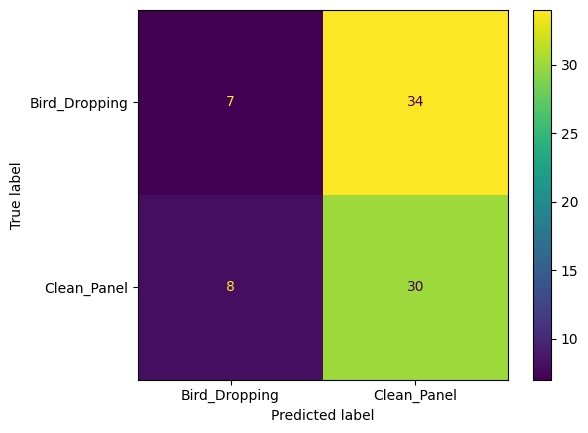

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Predict on validation set
val_preds = model.predict(val_data)
val_preds_binary = (val_preds > 0.5).astype("int32")
y_true = val_data.classes

print("Classification Report:")
print(classification_report(y_true, val_preds_binary, target_names=val_data.class_indices.keys()))

# Confusion Matrix
cm = confusion_matrix(y_true, val_preds_binary)
ConfusionMatrixDisplay(cm, display_labels=val_data.class_indices.keys()).plot()


In [ ]:
import os
from collections import Counter

train_dir = "processed_dataset_binary"
counter = {}
for category in os.listdir(train_dir):
    count = len(os.listdir(os.path.join(train_dir, category)))
    counter[category] = count
print("📊 Dataset Distribution:", counter)


📊 Dataset Distribution: {'Clean_Panel': 193, 'Bird_Dropping': 207}


In [ ]:
# Unfreeze last ~50 layers
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Retrain with more capacity
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks
)


Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.9268 - loss: 0.2207 - val_accuracy: 0.5570 - val_loss: 12.6048
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.9506 - loss: 0.1186 - val_accuracy: 0.6582 - val_loss: 6.4957
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9222 - loss: 0.1907 - val_accuracy: 0.7089 - val_loss: 4.3760
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9900 - loss: 0.0562 - val_accuracy: 0.6962 - val_loss: 6.6208
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9862 - loss: 0.0421 - val_accuracy: 0.6835 - val_loss: 5.4484


In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)


In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])


In [ ]:
model.save("bird_drop_detector.h5")


In [ ]:
# === Step 1: Setup - Download testing.zip from Google Drive ===
import gdown
import zipfile
import os

# Google Drive file ID (from your shared link)
file_id = "1oKhT-msjmutdOmzD2ifKdre9OfJZsoHu"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "testing.zip", quiet=False)

# Extract into 'testing/' folder
with zipfile.ZipFile("testing.zip", 'r') as zip_ref:
    zip_ref.extractall("testing")

print("✅ testing.zip downloaded and extracted into /content/testing")


Downloading...
From (original): https://drive.google.com/uc?id=1oKhT-msjmutdOmzD2ifKdre9OfJZsoHu
From (redirected): https://drive.google.com/uc?id=1oKhT-msjmutdOmzD2ifKdre9OfJZsoHu&confirm=t&uuid=0dff976f-2c62-4422-9666-d8df8e6a2286
To: /content/testing.zip
100%|██████████| 1.23G/1.23G [00:15<00:00, 79.6MB/s]


✅ testing.zip downloaded and extracted into /content/testing


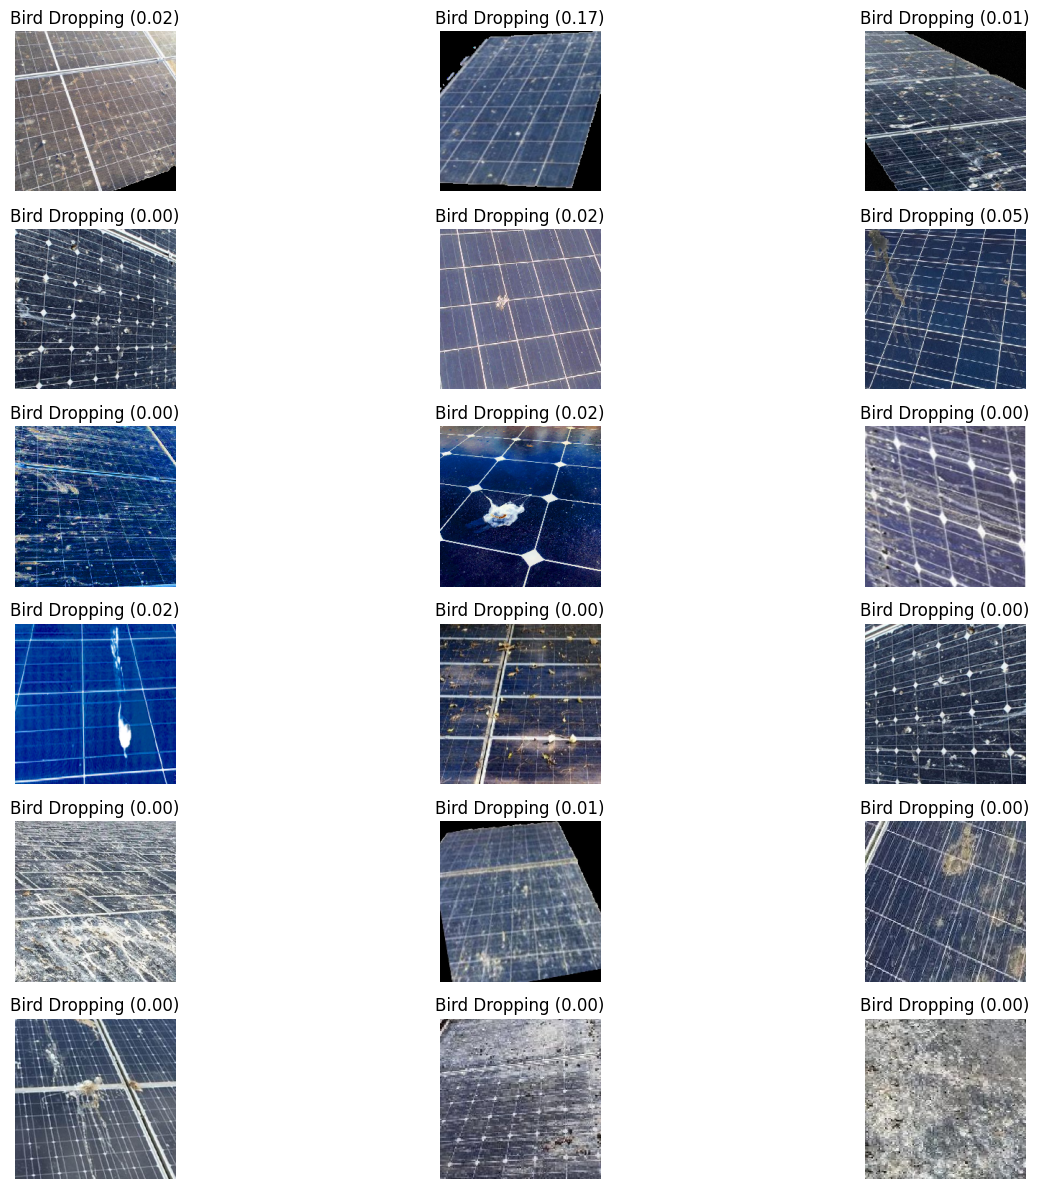


✅ Accuracy: 735/800 = 91.88%

📊 Classification Report:
               precision    recall  f1-score   support

Bird Dropping       0.89      0.95      0.92       400
  Clean Panel       0.95      0.89      0.92       400

     accuracy                           0.92       800
    macro avg       0.92      0.92      0.92       800
 weighted avg       0.92      0.92      0.92       800


❌ Misclassified Images:
37.png: Predicted = Clean Panel (0.8970), Actual = Bird Dropping
Bird (198)_aug_2.png: Predicted = Clean Panel (0.5208), Actual = Bird Dropping
65.png: Predicted = Clean Panel (0.6966), Actual = Bird Dropping
4_original.png: Predicted = Clean Panel (0.9192), Actual = Bird Dropping
aug_358.jpg: Predicted = Clean Panel (0.9316), Actual = Bird Dropping
2_original.png: Predicted = Clean Panel (0.5974), Actual = Bird Dropping
Bird (168)_aug_3.png: Predicted = Clean Panel (0.8766), Actual = Bird Dropping
16_aug_2.png: Predicted = Clean Panel (0.9280), Actual = Bird Dropping
Bird (127)_

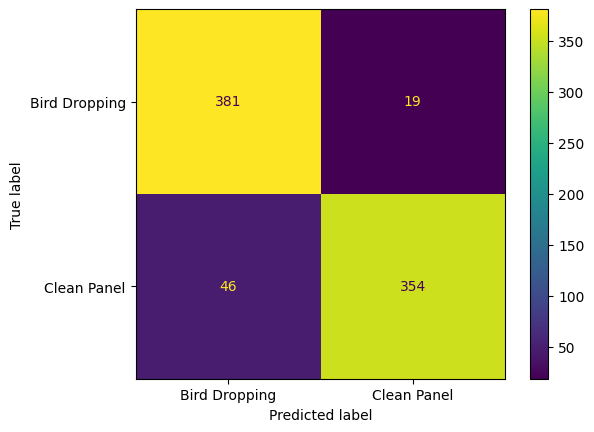

In [ ]:
# === Step 1: Import dependencies ===
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# === Step 2: Load the model ===
model = load_model("bird_drop_detector_final.h5")  # Upload this to Colab first

# === Step 3: Setup test data directory and categories ===
test_dir = "testing/testing"
categories = ["bird drop", "clean"]

# === Step 4: Initialize counters and plot setup ===
correct = 0
total = 0
threshold = 0.5
misclassified = []
y_true_labels = []
y_pred_labels = []

max_images_to_plot = 18
img_index = 1
plt.figure(figsize=(15, 12))

# === Step 5: Process test images ===
for label in categories:
    folder_path = os.path.join(test_dir, label)
    if not os.path.exists(folder_path):
        print(f"⚠️ Folder not found: {folder_path}")
        continue

    for fname in os.listdir(folder_path):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        fpath = os.path.join(folder_path, fname)

        try:
            img = image.load_img(fpath, target_size=(224, 224))
            img_array = image.img_to_array(img) / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            pred = model.predict(img_array, verbose=0)[0][0]
            pred_label = "Clean Panel" if pred > threshold else "Bird Dropping"
            actual_label = "Clean Panel" if label.lower().startswith("clean") else "Bird Dropping"

            # Collect for metrics
            y_true_labels.append(0 if actual_label == "Bird Dropping" else 1)
            y_pred_labels.append(0 if pred_label == "Bird Dropping" else 1)

            total += 1
            if pred_label == actual_label:
                correct += 1
            else:
                misclassified.append((fname, pred_label, actual_label, pred))

            if img_index <= max_images_to_plot:
                plt.subplot(6, 3, img_index)
                plt.imshow(img)
                plt.title(f"{pred_label} ({pred:.2f})")
                plt.axis("off")
                img_index += 1

        except Exception as e:
            print(f"❌ Error reading {fpath}: {e}")

plt.tight_layout()
plt.show()

# === Step 6: Accuracy ===
if total > 0:
    acc = correct / total * 100
    print(f"\n✅ Accuracy: {correct}/{total} = {acc:.2f}%")
else:
    print("⚠️ No valid test images found.")

# === Step 7: Classification Metrics ===
target_names = ["Bird Dropping", "Clean Panel"]

print("\n📊 Classification Report:")
print(classification_report(y_true_labels, y_pred_labels, target_names=target_names))

cm = confusion_matrix(y_true_labels, y_pred_labels)
ConfusionMatrixDisplay(cm, display_labels=target_names).plot()

# === Step 8: Show Misclassified Samples ===
if misclassified:
    print("\n❌ Misclassified Images:")
    for fname, pred_label, actual_label, conf in misclassified:
        print(f"{fname}: Predicted = {pred_label} ({conf:.4f}), Actual = {actual_label}")
else:
    print("🎉 No misclassifications found!")


In [ ]:
print(train_data.class_indices)


{'Bird_Dropping': 0, 'Clean_Panel': 1}
